In [ ]:
import pandas as pd
import numpy as np

df_raw = pd.read_excel("data/Telco_customer_churn.xlsx")

drop_cols = [
    "CustomerID", "Count",
    "Country", "State", "City", "Zip Code",
    "Lat Long", "Latitude", "Longitude",
    "Churn Label", "Churn Score", "Churn Reason",
    "CLTV",
    "Total Charges"       # composite of Tenure × Monthly Charges (r=0.826) — redundant
]

df = df_raw.drop(columns=drop_cols, errors='ignore')


df = df.dropna()

y = df["Churn Value"]
X = df.drop("Churn Value", axis=1)
X = pd.get_dummies(X, drop_first=True)

print("Final shape:", X.shape)       # expect (7043, ~30)
print("Nulls remaining:", X.isnull().sum().sum())  # expect 0
print("Target distribution:\n", y.value_counts())

print("=== FINAL PREPROCESSING SANITY CHECK ===")
print(f"Shape          : {X.shape}")
print(f"Rows           : {len(X)} / 7043 expected")
print(f"Nulls          : {X.isnull().sum().sum()}")
print(f"Target dist    :\n{y.value_counts()}")
print(f"Churn rate     : {y.mean():.1%}")
print(f"Feature dtypes :\n{X.dtypes.value_counts()}")
print(f"Any bool cols  : {list(X.select_dtypes('bool').columns)}")
print(f"Duplicate rows : {X.duplicated().sum()}")
# 1. Convert bool columns to int (breaks sklearn estimators)
X = X.astype({col: int for col in X.select_dtypes('bool').columns})

# 2. Drop 47 duplicate rows
X = X[~X.duplicated()]
y = y[X.index]  # keep y aligned

# 3. Confirm
print("Shape after fixes:", X.shape)          # expect (6996, 29)
print("Bool cols remaining:", list(X.select_dtypes('bool').columns))  # expect []
print("Duplicates remaining:", X.duplicated().sum())                   # expect 0
print("X/y aligned:", len(X) == len(y))                               # expect True
print("=== READY CHECK ===")
assert X.isnull().sum().sum() == 0,       "Nulls found"
assert X.duplicated().sum() == 0,         "Duplicates found"
assert len(X.select_dtypes('bool').columns) == 0, "Bool columns found"
assert len(X) == len(y),                  "X/y misaligned"
print("All checks passed. Ready for training.")

Final shape: (7043, 29)
Nulls remaining: 0
Target distribution:
 Churn Value
0    5174
1    1869
Name: count, dtype: int64
=== FINAL PREPROCESSING SANITY CHECK ===
Shape          : (7043, 29)
Rows           : 7043 / 7043 expected
Nulls          : 0
Target dist    :
Churn Value
0    5174
1    1869
Name: count, dtype: int64
Churn rate     : 26.5%
Feature dtypes :
bool       27
int64       1
float64     1
Name: count, dtype: int64
Any bool cols  : ['Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'Phone Service_Yes', 'Multiple Lines_No phone service', 'Multiple Lines_Yes', 'Internet Service_Fiber optic', 'Internet Service_No', 'Online Security_No internet service', 'Online Security_Yes', 'Online Backup_No internet service', 'Online Backup_Yes', 'Device Protection_No internet service', 'Device Protection_Yes', 'Tech Support_No internet service', 'Tech Support_Yes', 'Streaming TV_No internet service', 'Streaming TV_Yes', 'Streaming Movies_No internet service', 'Streamin

AssertionError: Bool columns found

Churn Reason    5174
dtype: int64
=== 5-Fold Stratified CV ===
AUC-ROC : 0.8340  ± 0.0056  | folds: [0.8329 0.832  0.8341 0.8268 0.8441]
F1      : 0.5591  ± 0.0150  | folds: [0.5497 0.5393 0.577  0.5534 0.576 ]
Recall  : 0.4981  ± 0.0245  | folds: [0.4733 0.4679 0.5107 0.5053 0.5335]

=== Hold-out test (threshold = 0.35) ===
AUC-ROC  : 0.8304
Accuracy : 0.7679

Confusion Matrix:
[[834 201]
 [126 248]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1035
           1       0.55      0.66      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409



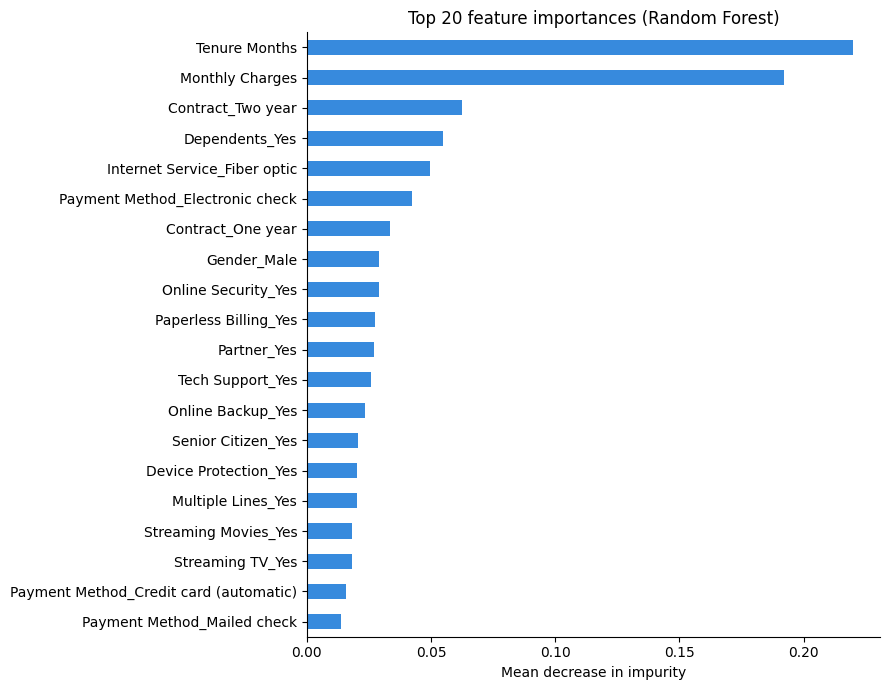


=== Top 10 features ===
Tenure Months                      0.219735
Monthly Charges                    0.191906
Contract_Two year                  0.062477
Dependents_Yes                     0.054743
Internet Service_Fiber optic       0.049566
Payment Method_Electronic check    0.042240
Contract_One year                  0.033305
Gender_Male                        0.029172
Online Security_Yes                0.028877
Paperless Billing_Yes              0.027243


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)


df = pd.read_excel("data/Telco_customer_churn.xlsx")
print(df.isnull().sum()[df.isnull().sum() > 0])

drop_cols = [
    "CustomerID", "Count",
    "Country", "State", "City", "Zip Code",
    "Lat Long", "Latitude", "Longitude",
    "Churn Label", "Churn Score", "Churn Reason",
    "CLTV",
    "Total Charges"      
]

df = df_raw.drop(columns=drop_cols, errors='ignore')
df = df.dropna()

y = df["Churn Value"]
X = df.drop("Churn Value", axis=1)
X = pd.get_dummies(X, drop_first=True)

#  Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#  Model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
)
model.fit(X_train, y_train)

#  StratifiedKFold CV 
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc   = cross_val_score(model, X, y, cv=skf, scoring="roc_auc",   n_jobs=-1)
cv_f1    = cross_val_score(model, X, y, cv=skf, scoring="f1",        n_jobs=-1)
cv_recall= cross_val_score(model, X, y, cv=skf, scoring="recall",    n_jobs=-1)

print("=== 5-Fold Stratified CV ===")
print(f"AUC-ROC : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}  | folds: {np.round(cv_auc, 4)}")
print(f"F1      : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}  | folds: {np.round(cv_f1, 4)}")
print(f"Recall  : {cv_recall.mean():.4f}  ± {cv_recall.std():.4f}  | folds: {np.round(cv_recall, 4)}")


THRESHOLD = 0.35

y_proba = model.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= THRESHOLD).astype(int)

print(f"\n=== Hold-out test (threshold = {THRESHOLD}) ===")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

TOP_N = 20

importances = model.feature_importances_
feat_series = pd.Series(importances, index=X.columns).sort_values(ascending=False)
top_feats   = feat_series.head(TOP_N)

fig, ax = plt.subplots(figsize=(9, 7))
top_feats[::-1].plot(kind="barh", ax=ax, color="#378ADD")
ax.set_xlabel("Mean decrease in impurity")
ax.set_title(f"Top {TOP_N} feature importances (Random Forest)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("feature_importances.png", dpi=150)
plt.show()

print("\n=== Top 10 features ===")
print(top_feats.head(10).to_string())